**DATA CLEANING FOR "PERSONAL PDI"**

**STEP 1: LOAD LIBRARIES AND DATASETS**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:

df = pd.read_excel("uc3m-personal-pdi-2023-anonimizado.xlsx")

**STEP 2: INITIAL INSPECTION**

In [15]:
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1798 entries, 0 to 1797
Data columns (total 64 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   IMPORTANTE                          1798 non-null   object 
 1   cod_universidad                     1798 non-null   int64  
 2   des_universidad                     1798 non-null   object 
 3   anio                                1798 non-null   int64  
 4   cod_pais_nacionalidad               1798 non-null   int64  
 5   des_pais_nacionalidad               1798 non-null   object 
 6   lat_pais_nacionalidad               1791 non-null   float64
 7   lon_pais_nacionalidad               1791 non-null   float64
 8   cod_continente_nacionalidad         1798 non-null   int64  
 9   des_continente_nacionalidad         1798 non-null   object 
 10  cod_agregacion_paises_nacionalidad  1798 non-null   int64  
 11  des_agregacion_paises_nacionalidad  1798 no

,cod_universidad,anio,cod_pais_nacionalidad,lat_pais_nacionalidad,lon_pais_nacionalidad,cod_continente_nacionalidad,cod_agregacion_paises_nacionalidad,cod_comunidad_residencia,cod_provincia_residencia,cod_municipio_residencia,...,cod_mencion_europea_int,cod_tipo_unidad_responsable,cod_unidad_responsable,cod_area_conocimiento,anio_incorporacion_ap,anio_incorpora_cuerpo_docente,num_trienios,num_quinquenios,num_sexenios,num_tesis
count,1798.0,1798.0,1798.000000,1791.000000,1791.000000,1798.000000,1798.000000,1796.000000,1796.000000,1796.000000,...,1220.000000,1798.0,1.778000e+03,1028.000000,717.000000,717.000000,1798.000000,1798.000000,1798.000000,1798.000000
mean,36.0,2023.0,706.464405,40.543394,-3.069633,149.017241,42.807008,12.752784,28.098552,28186.847996,...,0.004098,2.0,5.500211e+07,428.946498,1997.878661,2008.511855,4.280311,2.063404,1.377086,0.065628
std,0.0,0.0,87.347785,2.639043,9.509072,11.111527,28.694232,1.393226,3.444713,3452.690668,...,0.063913,0.0,5.651941e+02,246.214451,8.191019,10.506127,4.034818,2.203954,1.740598,0.330474
min,36.0,2023.0,40.000000,-9.189967,-106.346771,19.000000,21.000000,1.000000,1.000000,1059.000000,...,0.000000,2.0,5.500192e+07,10.000000,1973.000000,1979.000000,0.000000,0.000000,0.000000,0.000000
25%,36.0,2023.0,724.000000,40.463667,-3.749220,150.000000,39.000000,13.000000,28.000000,28074.000000,...,0.000000,2.0,5.500192e+07,160.000000,1993.000000,2001.000000,0.000000,0.000000,0.000000,0.000000
50%,36.0,2023.0,724.000000,40.463667,-3.749220,150.000000,39.000000,13.000000,28.000000,28079.000000,...,0.000000,2.0,5.500193e+07,520.000000,1998.000000,2009.000000,4.000000,1.000000,0.000000,0.000000
75%,36.0,2023.0,724.000000,40.463667,-3.749220,150.000000,39.000000,13.000000,28.000000,28079.000000,...,0.000000,2.0,5.500194e+07,595.000000,2004.000000,2019.000000,7.000000,4.000000,3.000000,0.000000
max,36.0,2023.0,887.000000,61.924110,138.252924,150.000000,419.000000,16.000000,50.000000,50297.000000,...,1.000000,2.0,5.500436e+07,800.000000,2022.000000,2023.000000,16.000000,6.000000,6.000000,5.000000


**STEP 3: CHECK MISSING VALUES**

In [16]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
anio_incorpora_cuerpo_docente,1081
anio_incorporacion_ap,1081
des_universidad_doctorado,1002
cod_universidad_doctorado,1002
lat_pais_doctorado,957
des_pais_doctorado,957
lon_pais_doctorado,957
cod_continente_doctorado,957
cod_agregacion_paises_doctorado,957
cod_pais_doctorado,957


Having inspentioned the columns with null values, most of them are related with the fact of having or not a doctorate. Those who do not have one, have no values for columns like des_universidad_doctorado. The null values in cod_unidad_responsable corresponds to those workers who are in leave of absence. Finally, for the num_horas_semanales_tiempo_parcial, it is filled with the hours just for those who work part time.

**STEP 4: INSPECTION OF DUPLICATES**

In [17]:
df.duplicated().sum()

np.int64(0)

No duplicates

**STEP 5: KEEP RELEVANT VARIABLES**

In [18]:
cols_keep = [
    "anio",
    "des_pais_nacionalidad",
    "des_genero",
    "anio_nacimiento",
    "des_tipo_personal",
    "des_categoria_cuerpo_escala",
    "des_tipo_contrato",
    "num_horas_semanales_tiempo_parcial",
    "des_situacion_administrativa",
    "des_dedicacion",
    "cod_unidad_responsable",
    "des_unidad_responsable",
    "cod_titulo_doctorado",
    "cod_mencion_europea_int",
    "num_trienios",
    "num_quinquenios",
    "num_sexenios",
    "num_tesis",
    "ind_investigador_principal"
]

df = df[cols_keep]

**STEP 6: ENSURE NUMERICAL VARIABLES ARE OF TYPE NUMERIC**

In [19]:
numeric_cols = [
    "cod_titulo_doctorado",
    "cod_mencion_europea_int",
    "num_trienios",
    "num_quinquenios",
    "num_sexenios",
    "num_tesis"
]

for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

**STEP 7: BASIC EDA**


Top values for des_pais_nacionalidad:
des_pais_nacionalidad
España                                             1685
Italia                                               39
Grecia                                               10
Estados Unidos de América                             5
Francia                                               5
Alemania                                              5
Portugal                                              5
Reino Unido de Gran Bretaña e Irlanda del Norte       4
Ucrania                                               4
Polonia                                               3
Name: count, dtype: int64

Top values for des_genero:
des_genero
Hombre    1214
Mujer      584
Name: count, dtype: int64

Top values for des_tipo_personal:
des_tipo_personal
Personal laboral          1081
Funcionario de carrera     716
Funcionario Interino         1
Name: count, dtype: int64

Top values for des_categoria_cuerpo_escala:
des_categoria_cuerpo_escala
Profesor Asoc

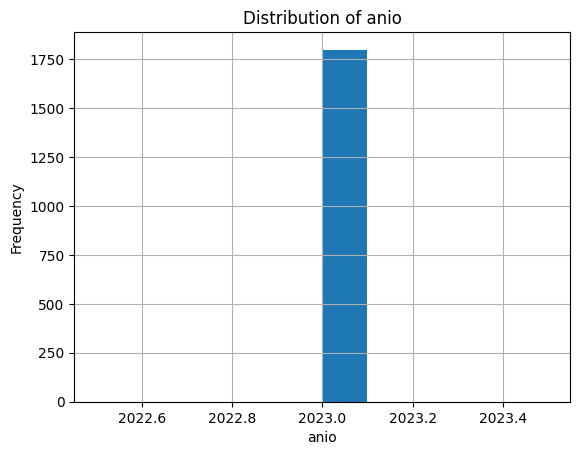

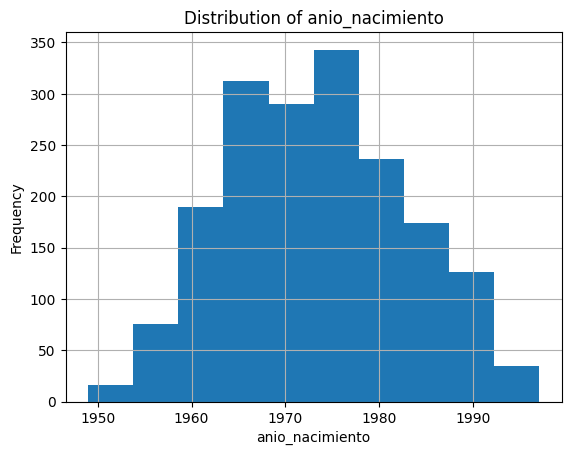

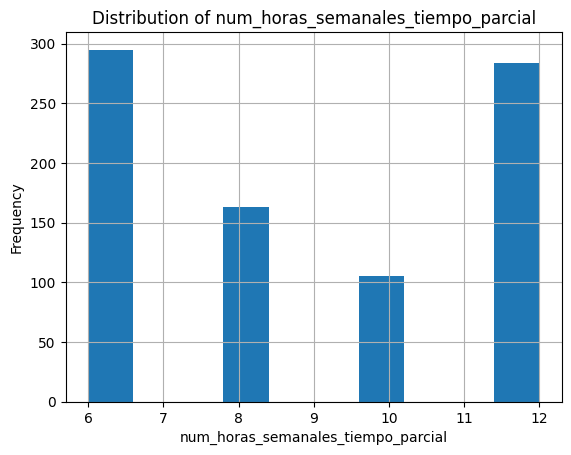

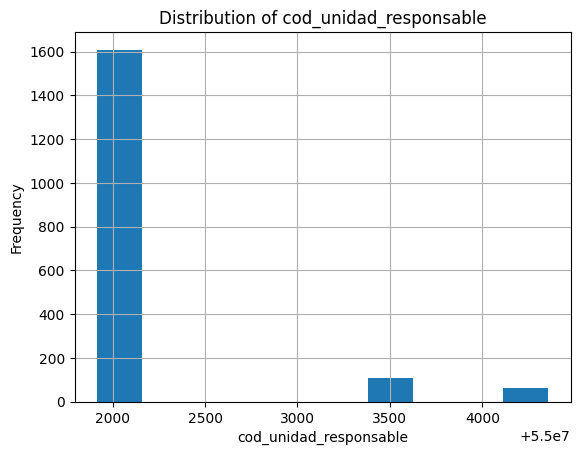

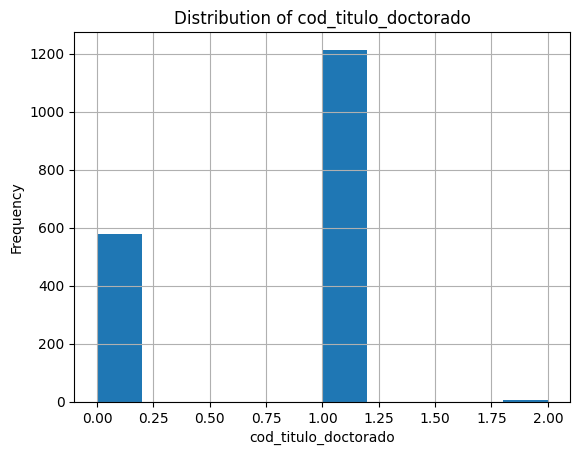

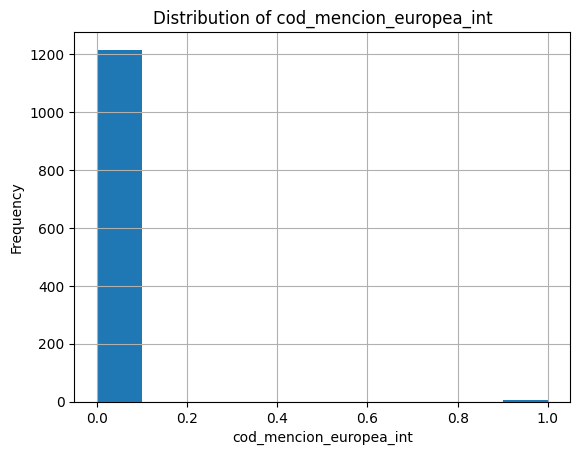

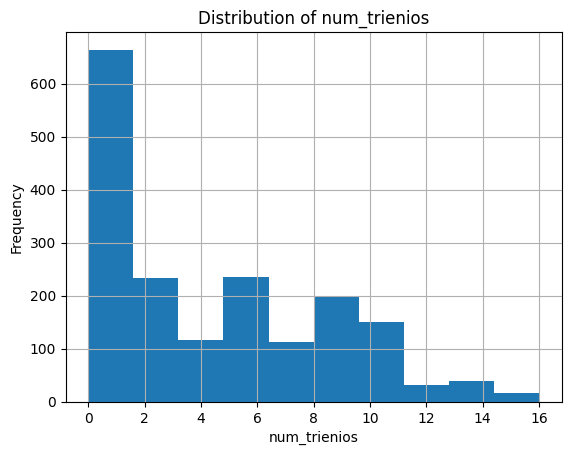

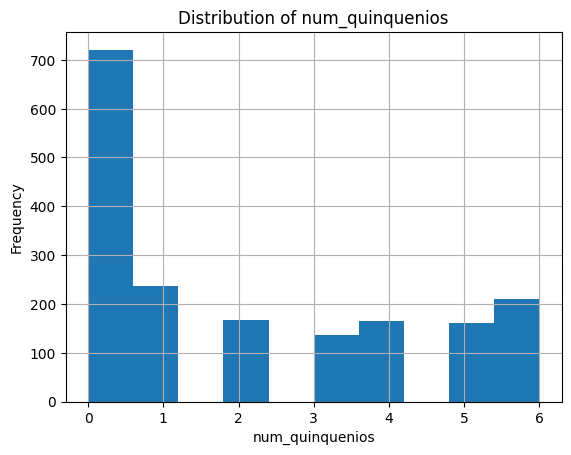

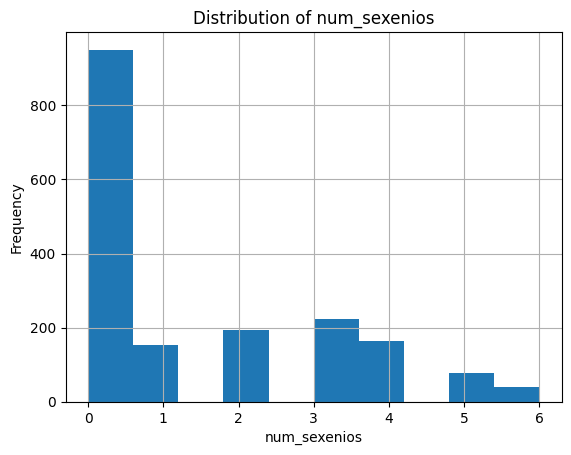

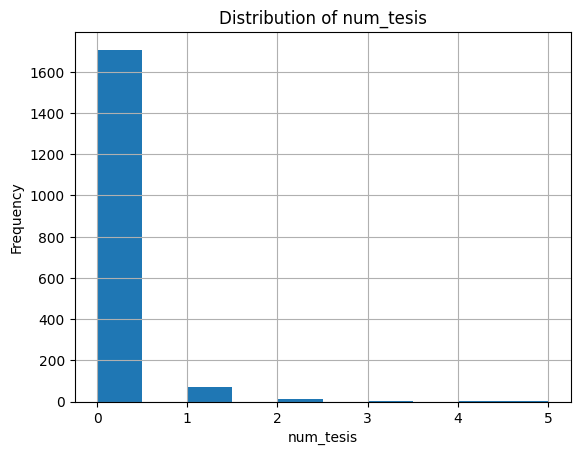

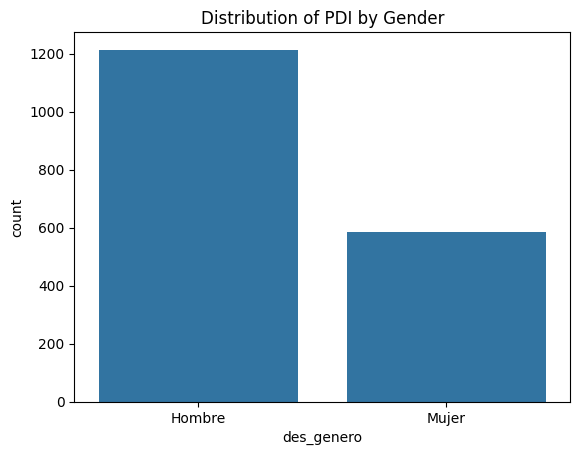

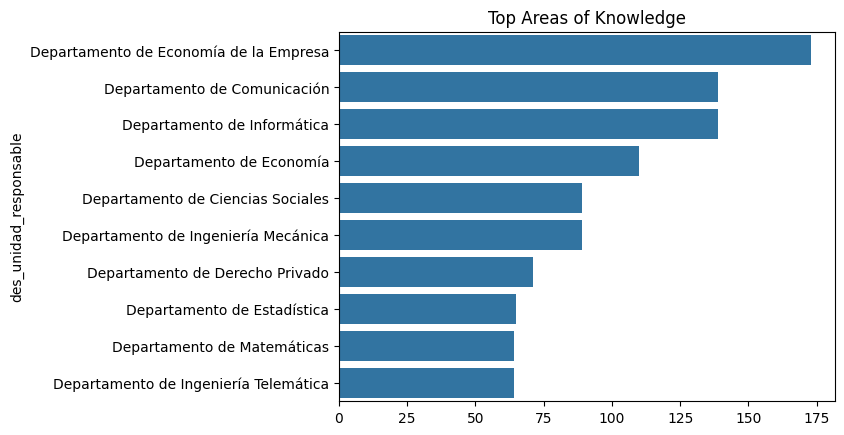

In [20]:
#Unique values for categorical variables
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\nTop values for {col}:")
    print(df[col].value_counts().head(10))


#Histograms for numerical variables
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure()
    df[col].hist()
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

#Specific observations:

#Ditribution by gender
sns.countplot(data=df, x="des_genero")
plt.title("Distribution of PDI by Gender")
plt.show()

#Proportion of staff with doctoral degree
df["cod_titulo_doctorado"].value_counts(normalize=True)

#Top areas of knowledge
pdi_area = df["des_unidad_responsable"].value_counts().head(10)

sns.barplot(x=pdi_area.values, y=pdi_area.index)
plt.title("Top Areas of Knowledge")
plt.show()

**STEP 8: SAVE IT**

In [21]:
df.to_excel("CLEAN(uc3m_pdi).xlsx", index=False)